In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download Apple stock data
stock_data = yf.download('AAPL', start='2024-01-01')

# Display first 10 rows
print(stock_data.head(10))

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.562180  186.330843  181.831767  185.055273  82488700
2024-01-03  182.187744  183.799505  181.376915  182.158081  58414500
2024-01-04  179.873932  181.040717  178.855462  180.111236  71983600
2024-01-05  179.152115  180.714432  178.153425  179.953062  62379700
2024-01-08  183.483078  183.522639  179.468523  180.051916  59144500
2024-01-09  183.067764  183.077647  180.684735  181.861418  42841800
2024-01-10  184.106033  184.313674  181.861437  182.286632  46792900
2024-01-11  183.512756  184.956422  181.564805  184.452120  49128400
2024-01-12  183.839035  184.649864  183.117210  183.977467  40477800
2024-01-16  181.574707  182.197645  178.904915  180.121159  65603000


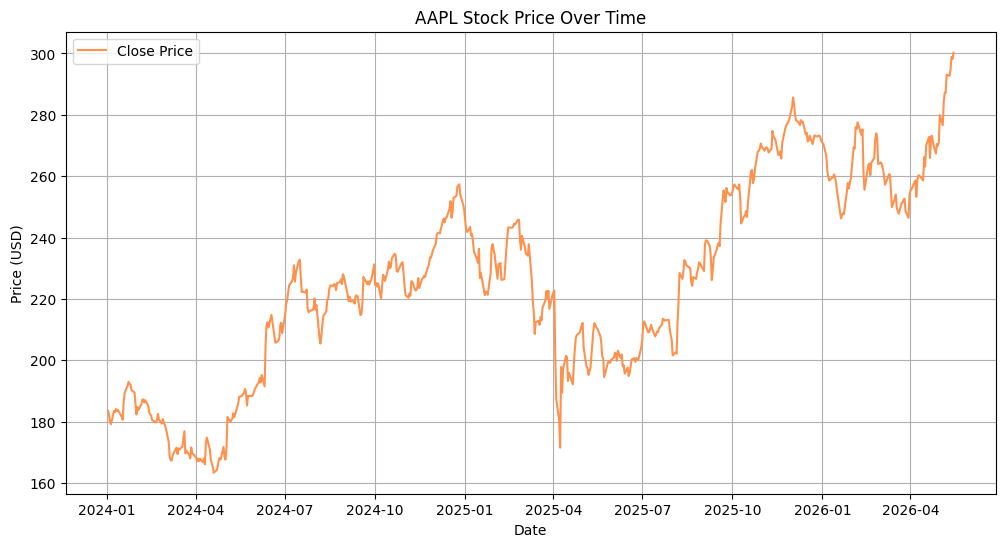

In [3]:
# Plot Closing Price
plt.figure(figsize=(12, 6))

plt.plot(
    stock_data.index,
    stock_data['Close'],
    label='Close Price',
    color='#FF914D'
)
# Graph labels and title
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# Show legend and grid
plt.legend()
plt.grid(True)

# Display plot
plt.show()

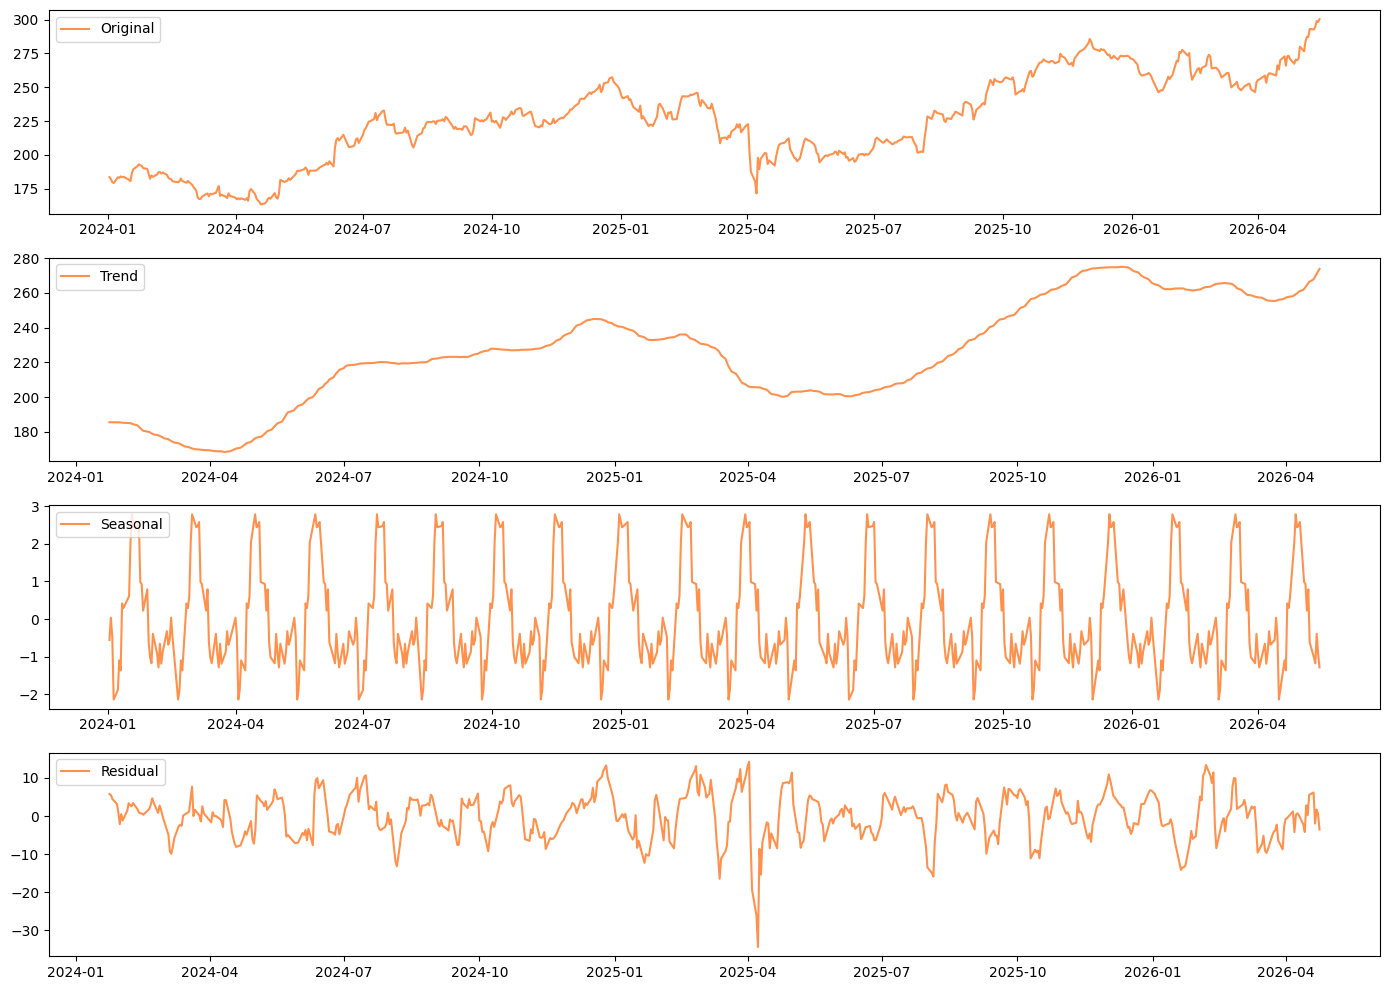

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform Additive Decomposition
decomposition_additive = seasonal_decompose(
    stock_data['Close'],
    model='additive',
    period=30
)

# Extract Components
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_additive = decomposition_additive.resid

# Plot Decomposition
plt.figure(figsize=(14, 10))

# Original Data
plt.subplot(411)
plt.plot(stock_data['Close'], label='Original', color='#FF914D')
plt.legend(loc='upper left')

# Trend Component
plt.subplot(412)
plt.plot(trend_additive, label='Trend', color='#FF914D')
plt.legend(loc='upper left')

# Seasonal Component
plt.subplot(413)
plt.plot(seasonal_additive, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')

# Residual Component
plt.subplot(414)
plt.plot(residual_additive, label='Residual', color='#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

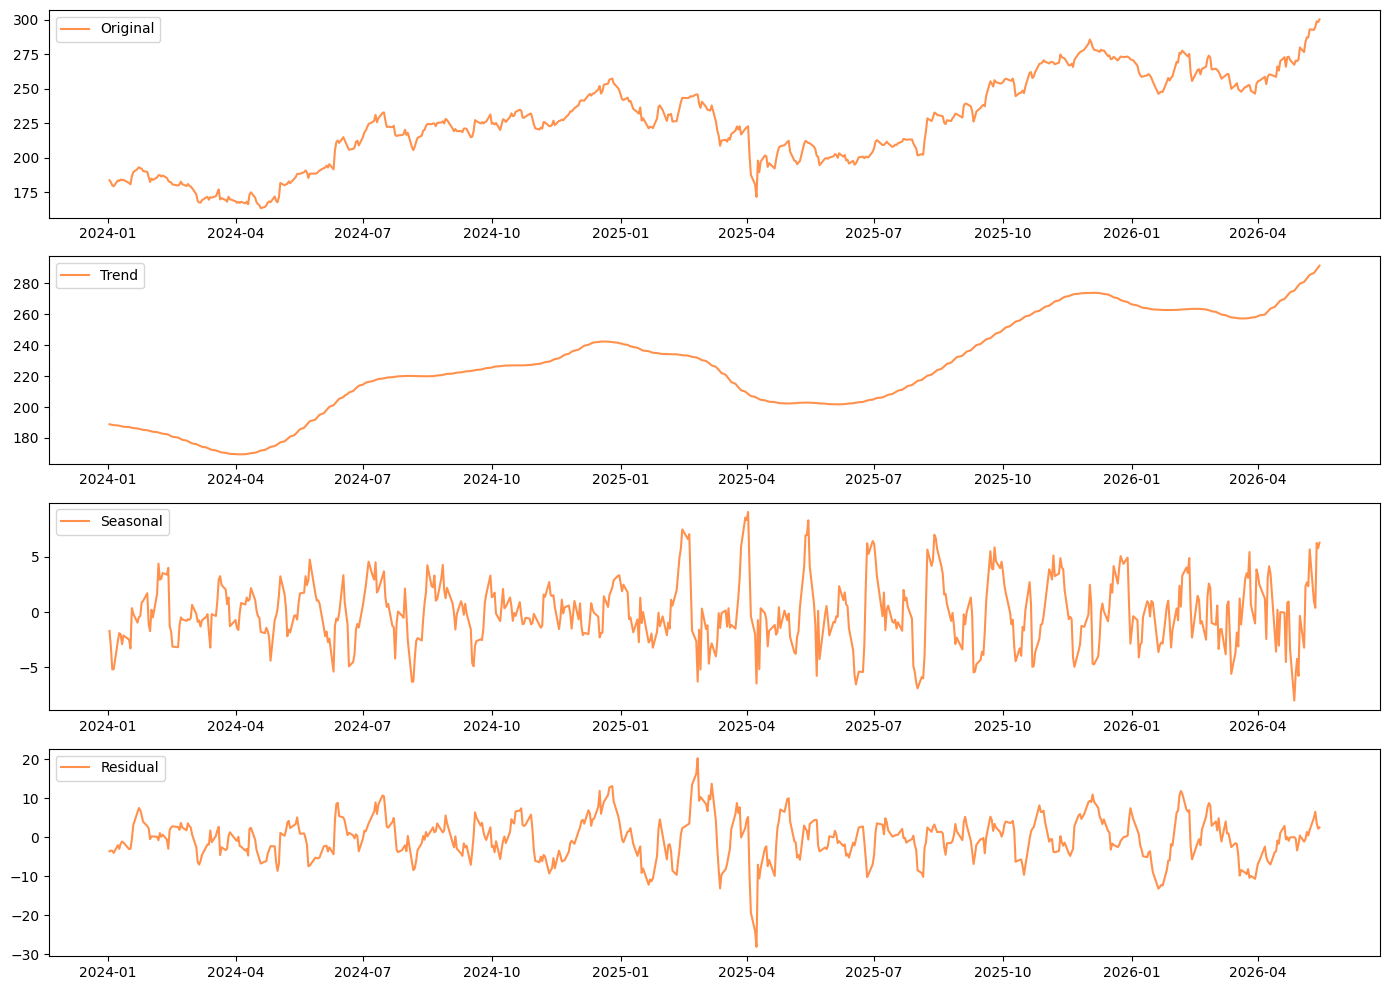

In [5]:
from statsmodels.tsa.seasonal import STL

# Perform STL decomposition
stl = STL(stock_data['Close'], period=30)
result = stl.fit()

# Plot the decomposition components
plt.figure(figsize=(14, 10))

# Original Data
plt.subplot(411)
plt.plot(result.observed, label='Original', color='#FF914D')
plt.legend(loc='upper left')

# Trend Component
plt.subplot(412)
plt.plot(result.trend, label='Trend', color='#FF914D')
plt.legend(loc='upper left')

# Seasonal Component
plt.subplot(413)
plt.plot(result.seasonal, label='Seasonal', color='#FF914D')
plt.legend(loc='upper left')

# Residual Component
plt.subplot(414)
plt.plot(result.resid, label='Residual', color='#FF914D')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(stock_data['Close'])

# Print ADF Test Results
print('ADF Test Results:')

print(f'ADF Statistic: {round(adf_test[0], 3)}')
print(f'p-value: {round(adf_test[1], 3)}')

print('Critical Values:')

for key, value in adf_test[4].items():
    print(f'   {key}: {round(value, 3)}')

ADF Test Results:
ADF Statistic: -0.762
p-value: 0.83
Critical Values:
   1%: -3.441
   5%: -2.866
   10%: -2.569


In [7]:
from statsmodels.tsa.stattools import kpss

# Perform the KPSS test
kpss_test = kpss(
    stock_data['Close'],
    regression='ct'   # 'c' for constant, 'ct' for trend
)

# Print KPSS Test Results
print('KPSS Test Results:')

print(f'KPSS Statistic: {round(kpss_test[0], 2)}')
print(f'p-value: {kpss_test[1]}')

print('Critical Values:')

for key, value in kpss_test[3].items():
    print(f'   {key}: {value}')

KPSS Test Results:
KPSS Statistic: 0.24
p-value: 0.01
Critical Values:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216


/tmp/ipykernel_18167/3392305211.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(


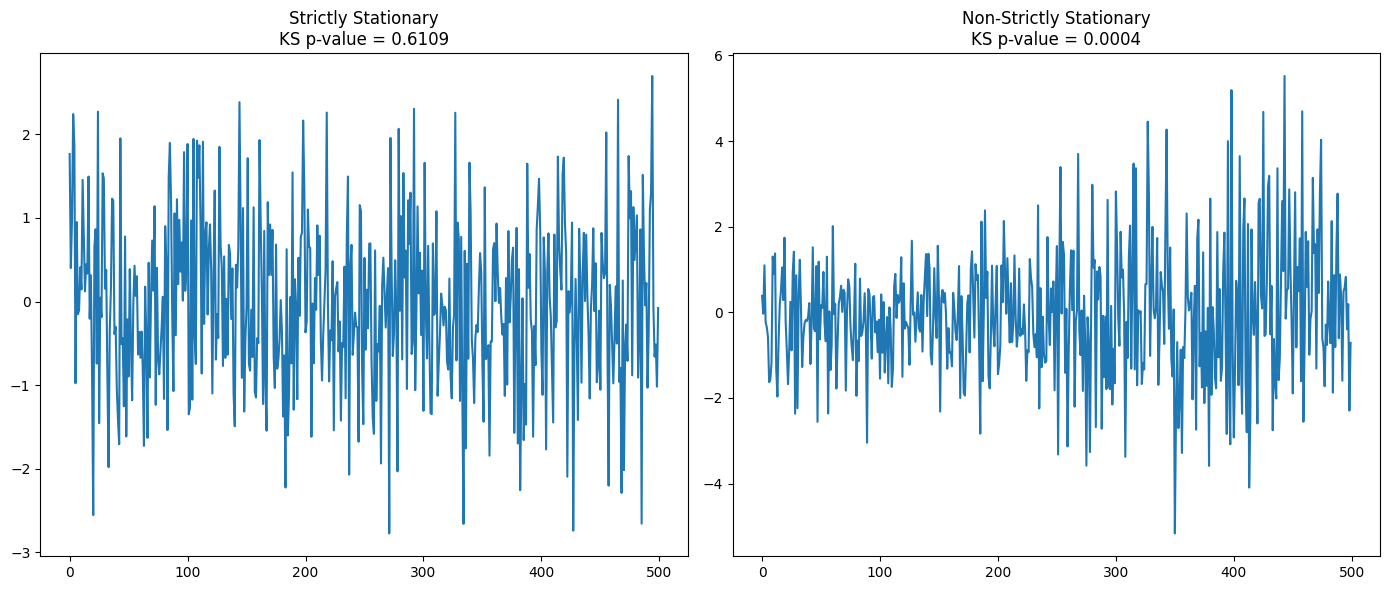

Strictly Stationary Series:
KS Statistic: 0.0680
P-value: 0.6109

Non-Strictly Stationary Series:
KS Statistic: 0.1840
P-value: 0.0004


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthetic data for demonstration
np.random.seed(0)
n = 500

# Strictly stationary series: normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)

# Non-strictly stationary series: changing variance
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 1, n // 2),
    np.random.normal(0, 2, n // 2)
])

# Function to split the series into two halves and perform the K-S test
def ks_test_stationarity(series):
    split = len(series) // 2

    series_first_half = series[:split]
    series_second_half = series[split:]

    stat, p_value = ks_2samp(
        series_first_half,
        series_second_half
    )

    return stat, p_value

# Perform the K-S test on strictly stationary series
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(
    strict_stationary_series
)

# Perform the K-S test on non-strictly stationary series
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity(
    non_strict_stationary_series
)

# Plotting the series
plt.figure(figsize=(14, 6))

# Strictly Stationary Series
plt.subplot(121)
plt.plot(strict_stationary_series)
plt.title(
    f'Strictly Stationary\nKS p-value = {ks_pvalue_strict:.4f}'
)

# Non-Strictly Stationary Series
plt.subplot(122)
plt.plot(non_strict_stationary_series)
plt.title(
    f'Non-Strictly Stationary\nKS p-value = {ks_pvalue_non_strict:.4f}'
)

plt.tight_layout()
plt.show()

# Print Results
print("Strictly Stationary Series:")
print(f"KS Statistic: {ks_stat_strict:.4f}")
print(f"P-value: {ks_pvalue_strict:.4f}")

print("\nNon-Strictly Stationary Series:")
print(f"KS Statistic: {ks_stat_non_strict:.4f}")
print(f"P-value: {ks_pvalue_non_strict:.4f}")

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss

# Performing ADF and KPSS tests

def adf_test(series):
    result = adfuller(series)

    print('ADF Statistic:', result[0])
    print('p-value:', result[1])

    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))


def kpss_test(series):
    result = kpss(series, regression='c')

    print('KPSS Statistic:', result[0])
    print('p-value:', result[1])

    for key, value in result[3].items():
        print('Critical Value (%s): %.3f' % (key, value))

In [40]:
# Select closing prices
prices = stock_data[('Close', 'AAPL')].squeeze()

# Run ADF Test
adf_test(prices)

ADF Statistic: -0.7624463056948796
p-value: 0.8299051245227118
Critical Value (1%): -3.441
Critical Value (5%): -2.866
Critical Value (10%): -2.569


In [11]:
# Display original price series
prices

Ticker,AAPL
Date,
2024-01-02,183.562180
2024-01-03,182.187744
2024-01-04,179.873932
2024-01-05,179.152115
2024-01-08,183.483078
...,...
2026-05-11,292.679993
2026-05-12,294.799988
2026-05-13,298.869995


In [22]:
# First-order differencing
prices_diff = prices.diff()

In [13]:
import numpy as np
from scipy import stats

# Log transformation
prices_log = np.log(prices)

# Square root transformation
prices_sqrt = np.sqrt(prices)

# Box-Cox transformation
# Note: Box-Cox requires all positive values
prices_boxcox, lam = stats.boxcox(prices['AAPL'][prices['AAPL'] > 0])

In [15]:
prices_log

Ticker,AAPL
Date,
2024-01-02,5.212553
2024-01-03,5.205038
2024-01-04,5.192256
2024-01-05,5.188235
2024-01-08,5.212122
...,...
2026-05-11,5.679080
2026-05-12,5.686297
2026-05-13,5.700009


In [16]:
prices_sqrt

Ticker,AAPL
Date,
2024-01-02,13.548512
2024-01-03,13.497694
2024-01-04,13.411709
2024-01-05,13.384772
2024-01-08,13.545593
...,...
2026-05-11,17.107893
2026-05-12,17.169740
2026-05-13,17.287857


In [17]:
prices_boxcox

array([124.37642839, 123.52245603, 122.08349199, 121.6342475 ,
       124.32729643, 124.06930286, 124.71417731, 124.34573062,
       124.54837505, 123.14137059, 122.55718314, 126.21143205,
       128.00702835, 129.43312844, 130.22203268, 129.80624175,
       129.6044033 , 128.53358503, 128.11113795, 125.84954881,
       123.61462703, 125.12548964, 124.50540008, 125.62868983,
       126.62225627, 126.68967975, 126.0213034 , 126.49410679,
       125.45001654, 124.15293055, 123.60540929, 123.4269301 ,
       122.47268816, 122.0106725 , 122.47885795, 123.7407761 ,
       122.6020195 , 121.76420871, 122.66976448, 121.92443054,
       121.51153006, 120.83949479, 118.02397616, 114.94147152,
       114.3215282 , 114.24708348, 115.31949599, 116.5704031 ,
       116.86745254, 115.56730668, 116.72511283, 116.4899307 ,
       117.17061434, 118.62960984, 120.22880524, 115.71594478,
       116.27946097, 115.3938333 , 114.68732587, 116.91695505,
       115.78409046, 114.88569477, 114.14785776, 114.65

In [18]:
adf_test(prices_boxcox)

ADF Statistic: -0.7889949479453534
p-value: 0.8223333635279569
Critical Value (1%): -3.441
Critical Value (5%): -2.866
Critical Value (10%): -2.569


In [26]:
adf_test(prices_diff.dropna())

ADF Statistic: -22.984496279398243
p-value: 0.0
Critical Value (1%): -3.441
Critical Value (5%): -2.866
Critical Value (10%): -2.569


In [35]:
from scipy import signal
import pandas as pd

# Using a linear trend
trend = np.polyfit(np.arange(len(prices)),prices,1)

trendline = np.polyval(
    trend,
    np.arange(len(prices))
)

prices_detrended = prices - pd.Series(trendline, index=prices.index)

In [41]:
adf_test(prices_detrended.iloc[:, 0])

MissingDataError: exog contains inf or nans

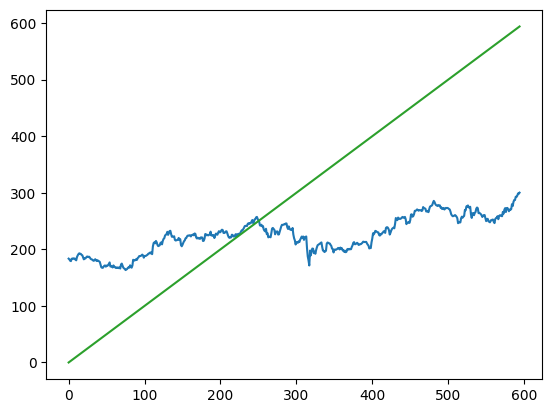

In [43]:
plt.plot(np.arange(len(prices)),prices,1)
plt.plot(np.arange(len(prices)))

In [47]:
# Using a moving average to remove trend

window = 12   # example window size

prices_ma = prices.rolling(window=window).mean()

prices_detrended = prices - prices_ma

prices_detrended = prices_detrended.dropna()

In [48]:
adf_test(prices_detrended)

ADF Statistic: -7.806894197827203
p-value: 7.241330129927886e-12
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


In [49]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition using moving averages
decomposition = seasonal_decompose(
    prices,
    model='additive',
    period=30
)

prices_adjusted = prices / decomposition.seasonal

prices_adjusted = prices_adjusted.dropna()

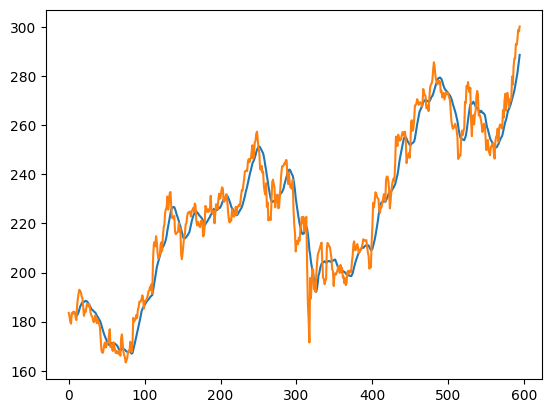

In [51]:
plt.plot(np.arange(len(prices)), prices_ma)

plt.plot(np.arange(len(prices)), prices)

plt.show()

In [50]:
adf_test(prices_detrended)

ADF Statistic: -7.806894197827203
p-value: 7.241330129927886e-12
Critical Value (1%): -3.442
Critical Value (5%): -2.867
Critical Value (10%): -2.569


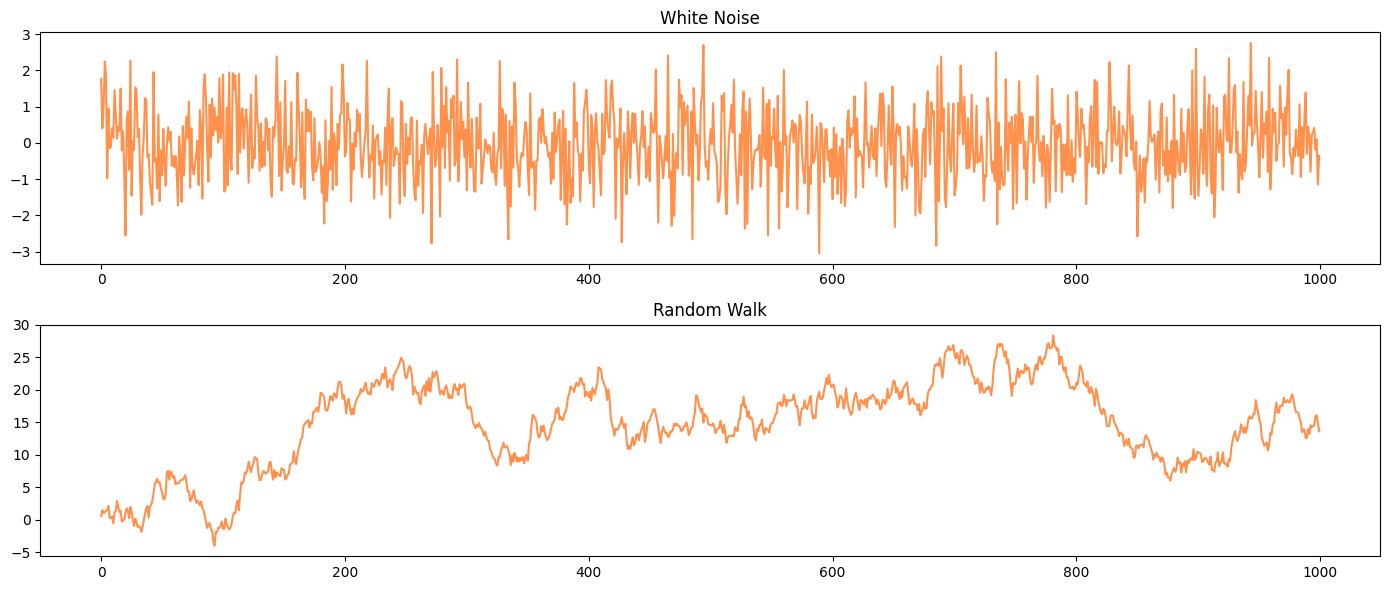


Ljung-Box Test for White Noise:
      lb_stat  lb_pvalue
10  14.025574   0.171828

Ljung-Box Test for Random Walk:
        lb_stat  lb_pvalue
10  8828.660312        0.0


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# Generating white noise and random walk for comparison
np.random.seed(0)

n = 1000

# White Noise
white_noise = np.random.normal(0, 1, n)

# Random Walk
random_shocks = np.random.normal(0, 1, n)
random_walk = np.cumsum(random_shocks)

# Plotting the series
plt.figure(figsize=(14, 6))

# White Noise Plot
plt.subplot(2, 1, 1)
plt.plot(white_noise, color='#FF914D')
plt.title('White Noise')

# Random Walk Plot
plt.subplot(2, 1, 2)
plt.plot(random_walk, color='#FF914D')
plt.title('Random Walk')

plt.tight_layout()
plt.show()

# Ljung-Box test for White Noise
print("\nLjung-Box Test for White Noise:")

lb_test_white_noise = acorr_ljungbox(
    white_noise,
    lags=[10],
    return_df=True
)

print(lb_test_white_noise)

# Ljung-Box test for Random Walk
print("\nLjung-Box Test for Random Walk:")

lb_test_random_walk = acorr_ljungbox(
    random_walk,
    lags=[10],
    return_df=True
)

print(lb_test_random_walk)